# Linear-System Classical Baselines vs QSVT Resource Proxies

This notebook treats a finite-difference Poisson system as a package-client benchmark. It compares dense linear solve (DLS) and conjugate gradient solve (CGS) baselines against a QSVT inverse-polynomial resource proxy.

## Setup

In [1]:
import json
from pathlib import Path

import numpy as np

from qsvt import (
    conjugate_gradient_benchmark,
    dense_linear_solve_benchmark,
    design_positive_inverse_polynomial,
    dirichlet_laplacian_1d,
    plot_benchmark_timings,
    plot_qsvt_proxy_resources,
    report_to_jsonable,
    save_report,
    write_benchmark_summary_csv,
)


def find_repo_root(start=Path.cwd()):
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise RuntimeError("could not locate repository root")


ROOT = find_repo_root()
ARTIFACT_DIR = ROOT / "results/benchmarks"
TABLE_DIR = ROOT / "results/tables"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

## Poisson System

In [2]:
n = 12
grid, operator = dirichlet_laplacian_1d(n)
rhs = np.sin(np.pi * grid)

eigenvalues = np.linalg.eigvalsh(operator)
gamma = float(np.min(eigenvalues) / np.max(eigenvalues))
inverse_coeffs = design_positive_inverse_polynomial(gamma=gamma, degree=9)

problem_summary = {
    "dimension": n,
    "condition_number": float(np.linalg.cond(operator)),
    "gamma": gamma,
    "inverse_degree": len(inverse_coeffs) - 1,
}
print(json.dumps(report_to_jsonable(problem_summary), indent=2))

{
  "dimension": 12,
  "condition_number": 67.82742906960378,
  "gamma": 0.014743298009626938,
  "inverse_degree": 9
}


## Baseline Reports

## Quantum-Advantage Interpretation

For this small dense notebook problem, DLS and CGS are the right classical references and no quantum advantage is claimed. A QSVT linear-system solver can become interesting only in a larger sparse or block-encoded regime where state preparation is efficient, the condition number is controlled, and the desired output is a state or expectation value rather than a full classical solution vector. The proxy below isolates the inverse-polynomial degree and signal-call count so users can see which part of a possible quantum workflow would need to beat the classical baseline.

{
  "dense_relative_residual": 2.781635782377763e-15,
  "cg_relative_residual": 7.682021639202151e-15,
  "cg_iterations": 1,
  "qsvt_signal_calls": 9
}


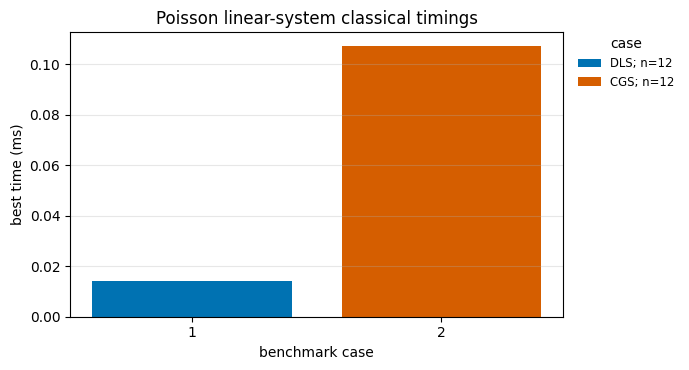

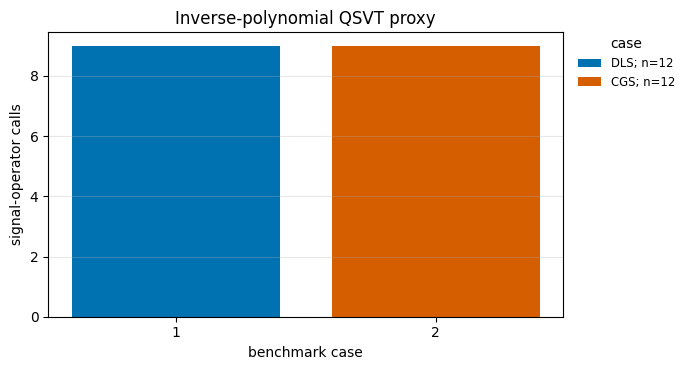

In [3]:
dense_report = dense_linear_solve_benchmark(
    operator,
    rhs,
    repeats=3,
    qsvt_coeffs=inverse_coeffs,
)
cg_report = conjugate_gradient_benchmark(
    operator,
    rhs,
    tolerance=1e-10,
    repeats=3,
    qsvt_coeffs=inverse_coeffs,
)

save_report(dense_report, ARTIFACT_DIR / "linear_system_dense_solve.json")
save_report(cg_report, ARTIFACT_DIR / "linear_system_cg_solve.json")
write_benchmark_summary_csv(
    [dense_report, cg_report],
    TABLE_DIR / "linear_system_benchmark_summary.csv",
)

summary = {
    "dense_relative_residual": dense_report["metrics"]["relative_residual_norm"],
    "cg_relative_residual": cg_report["metrics"]["relative_residual_norm"],
    "cg_iterations": cg_report["metrics"]["iterations"],
    "qsvt_signal_calls": cg_report["qsvt_proxy"]["resources"]["signal_operator_calls"],
}
print(json.dumps(report_to_jsonable(summary), indent=2))

reports = [dense_report, cg_report]
_ = plot_benchmark_timings(reports, title="Poisson linear-system classical timings")
_ = plot_qsvt_proxy_resources(reports, title="Inverse-polynomial QSVT proxy")